In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from pathlib import Path
import struct
import os
from datetime import datetime
from collections import Counter

In [30]:
DATA_PATH = Path("C:/Users/Devesh/Downloads/N-MINST")
print(f"Path exists: {DATA_PATH.exists()}")

Path exists: True


In [31]:
# Set plot style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [32]:
def load_nmist_bin(file_path):
    with open(file_path, 'rb') as f:
        raw_data = np.fromfile(f, dtype = np.uint8)
    
    # Each Event is 5 Bytes 
    
    n_events = len(raw_data) // 5      # weare have each event ad 5 bytes so weare dividing entire data into 5 to get number of events

    x = np.zeros(n_events, dtype =np.uint16)     # unit16 range 0 to 65,535 
    y = np.zeros(n_events, dtype =np.uint16)
    t = np.zeros(n_events, dtype =np.uint32)     # unit32 range 0 to 4 billion 
    p = np.zeros(n_events, dtype =np.uint8)      # unit8 range 0 to 255 so to store 1 value i.e P = 0 or 1 is sufficient 

    for i in range(n_events):
        idx = i*5

        x[i] = raw_data[idx]
        y[i] = raw_data[idx+1]

        t_raw = (raw_data[idx+2] | raw_data[idx+3]<<8 | raw_data[idx+4]<<16)  # Performing right shift to move bits 

        p[i] = t_raw & 1    # multiply LSB with 1 we will get p value i.e 0*1=0 and 1*1=1
        t[i] = t_raw >>1    # removing last bit i.e LSB as we stored LSB in p[i] (LeftShift Operation)
    events = np.zeros(n_events, dtype=[
        ('t', np.uint32),
        ('x', np.uint16),
        ('y', np.uint16),
        ('p', np.uint8)
    ])

    events['t'] = t
    events['x'] = x
    events['y'] = y
    events['p'] = p

    return events 

In [19]:
if DATA_PATH.exists():
    folders = sorted([f for f in DATA_PATH.iterdir() if f.is_dir()])
    print(f"Available folders: {[f.name for f in folders]}")
    print()

    for folder in folders[:2]:
        print("Folder name: ",{folder.name})
        binary_files = sorted(list(folder.glob("*.bin")))
        print(f"Total bin files: {len(binary_files)}")

        if len(binary_files)>0:
            print("First 5 Bin files")
            for f in binary_files[:5]:
                size_kb = f.stat().st_size / 1024
                print(f"    - {f.name} ({size_kb:.2f} KB)")
        print()
else:
    print("Please set correct DATA_PATH")

Available folders: ['0', '1']

Folder name:  {'0'}
Total bin files: 5923
First 5 Bin files
    - 00002.bin (24.55 KB)
    - 00022.bin (27.08 KB)
    - 00035.bin (24.36 KB)
    - 00038.bin (24.99 KB)
    - 00052.bin (31.56 KB)

Folder name:  {'1'}
Total bin files: 6742
First 5 Bin files
    - 00004.bin (13.30 KB)
    - 00007.bin (14.55 KB)
    - 00009.bin (10.23 KB)
    - 00015.bin (10.41 KB)
    - 00024.bin (12.79 KB)



In [33]:
# Try to load first file form folder '0'
sample_file = None
if DATA_PATH.exists():
    folder_0 = DATA_PATH / "0"
    if folder_0.exists():
        bin_files = sorted(list(folder_0.glob("*.bin")))
        if len(bin_files) > 0:
            sample_file = bin_files[0]


In [35]:
# Load or create sample data
if sample_file and sample_file.exists():
    print(f"Loading: {sample_file}")
    events = load_nmist_bin(sample_file)
    print(f"✓ Loaded successfully!")
    print()
else:
    print("⚠️  No data found. Creating synthetic sample for demonstration...")
    # Create synthetic events for demonstration
    n_events = 5000
    events = np.zeros(n_events, dtype=[
        ('t', np.uint32),
        ('x', np.uint16),
        ('y', np.uint16),
        ('p', np.uint8)
    ])
    events['t'] = np.sort(np.random.randint(0, 100000, n_events))
    events['x'] = np.random.randint(0, 34, n_events)
    events['y'] = np.random.randint(0, 34, n_events)
    events['p'] = np.random.randint(0, 2, n_events)
    print("✓ Synthetic data created")
    print()

# Display basic info
print(f"Event array shape: {events.shape}")
print(f"Event array dtype: {events.dtype}")
print()

Loading: C:\Users\Devesh\Downloads\N-MINST\0\00002.bin
✓ Loaded successfully!

Event array shape: (5028,)
Event array dtype: [('t', '<u4'), ('x', '<u2'), ('y', '<u2'), ('p', 'u1')]



In [36]:
n_events = len(events)
print(f"Total number of events: {n_events:,}")
print()

Total number of events: 5,028



In [38]:
# Time statistics
t_min = events['t'].min()
t_max = events['t'].max()
duration_us = t_max - t_min
duration_ms = duration_us / 1000
duration_s = duration_us / 1e6

print("TIME STATISTICS")
print("-" * 70)
print(f"First timestamp:     {t_min:,} μs")
print(f"Last timestamp:      {t_max:,} μs")
print(f"Duration:            {duration_us:,} μs")
print(f"                     {duration_ms:.2f} ms")
print(f"                     {duration_s:.4f} seconds")
print(f"Average event rate:  {n_events / duration_s:.2f} events/second")
print()

TIME STATISTICS
----------------------------------------------------------------------
First timestamp:     0 μs
Last timestamp:      66 μs
Duration:            66 μs
                     0.07 ms
                     0.0001 seconds
Average event rate:  76181818.18 events/second



In [39]:

# Spatial statistics
x_min, x_max = events['x'].min(), events['x'].max()
y_min, y_max = events['y'].min(), events['y'].max()

print("SPATIAL STATISTICS")
print("-" * 70)
print(f"Sensor resolution:   34 x 34 pixels (N-MNIST standard)")
print(f"X range:             [{x_min}, {x_max}]")
print(f"Y range:             [{y_min}, {y_max}]")
print(f"Spatial coverage:    {x_max - x_min + 1} x {y_max - y_min + 1} pixels")
print()

SPATIAL STATISTICS
----------------------------------------------------------------------
Sensor resolution:   34 x 34 pixels (N-MNIST standard)
X range:             [0, 33]
Y range:             [0, 33]
Spatial coverage:    34 x 34 pixels



In [40]:
# Polarity statistics
n_on = np.sum(events['p'] == 1)
n_off = np.sum(events['p'] == 0)
on_percent = (n_on / n_events) * 100
off_percent = (n_off / n_events) * 100

print("POLARITY DISTRIBUTION")
print("-" * 70)
print(f"ON events (p=1):     {n_on:,} ({on_percent:.2f}%)")
print(f"OFF events (p=0):    {n_off:,} ({off_percent:.2f}%)")
print(f"ON/OFF ratio:        {n_on/n_off:.3f}" if n_off > 0 else "ON/OFF ratio: N/A")
print()


POLARITY DISTRIBUTION
----------------------------------------------------------------------
ON events (p=1):     1,626 (32.34%)
OFF events (p=0):    3,402 (67.66%)
ON/OFF ratio:        0.478



In [41]:

# Event inter-arrival times
inter_arrival_times = np.diff(events['t'])
print("INTER-ARRIVAL TIME STATISTICS")
print("-" * 70)
print(f"Mean inter-arrival:  {np.mean(inter_arrival_times):.2f} μs")
print(f"Median inter-arrival: {np.median(inter_arrival_times):.2f} μs")
print(f"Min inter-arrival:   {np.min(inter_arrival_times)} μs")
print(f"Max inter-arrival:   {np.max(inter_arrival_times)} μs")
print()

INTER-ARRIVAL TIME STATISTICS
----------------------------------------------------------------------
Mean inter-arrival:  1079081697.80 μs
Median inter-arrival: 64.00 μs
Min inter-arrival:   0 μs
Max inter-arrival:   4294967232 μs



In [42]:
# Spatial distribution
print("SPATIAL ACTIVITY")
print("-" * 70)
x_hist, _ = np.histogram(events['x'], bins=34, range=(0, 33))
y_hist, _ = np.histogram(events['y'], bins=34, range=(0, 33))
print(f"Most active X column: {np.argmax(x_hist)} ({x_hist.max()} events)")
print(f"Most active Y row:    {np.argmax(y_hist)} ({y_hist.max()} events)")
print(f"Least active X column: {np.argmin(x_hist)} ({x_hist.min()} events)")
print(f"Least active Y row:    {np.argmin(y_hist)} ({y_hist.min()} events)")
print()

SPATIAL ACTIVITY
----------------------------------------------------------------------
Most active X column: 12 (320 events)
Most active Y row:    15 (284 events)
Least active X column: 30 (3 events)
Least active Y row:    2 (3 events)



In [43]:
# First and last events
print("SAMPLE EVENTS")
print("-" * 70)
print("First 5 events:")
print(f"{'#':<6} {'Time(μs)':<12} {'X':<4} {'Y':<4} {'Polarity'}")
print("-" * 40)
for i in range(min(5, len(events))):
    pol_str = "ON" if events['p'][i] == 1 else "OFF"
    print(f"{i:<6} {events['t'][i]:<12} {events['x'][i]:<4} {events['y'][i]:<4} {pol_str}")
print()

SAMPLE EVENTS
----------------------------------------------------------------------
First 5 events:
#      Time(μs)     X    Y    Polarity
----------------------------------------
0      64           10   30   OFF
1      64           33   20   OFF
2      64           12   27   OFF
3      64           33   3    OFF
4      0            14   23   OFF



🎨 CREATING SPATIAL VISUALIZATION
----------------------------------------------------------------------


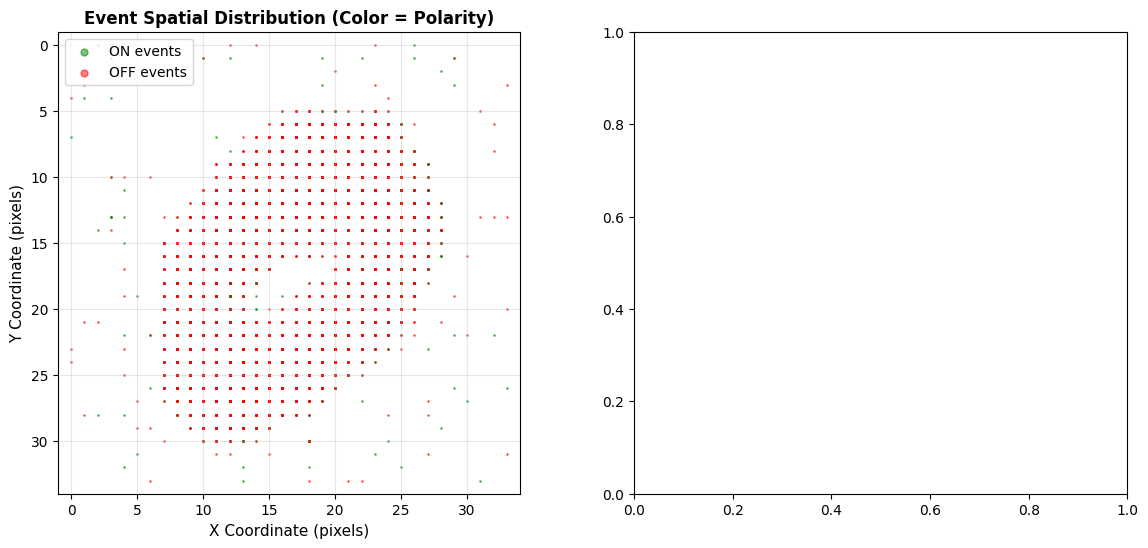

In [44]:
# ## 8. Visualization 1: Spatial Distribution (Scatter Plot)

# %%
print("🎨 CREATING SPATIAL VISUALIZATION")
print("-" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: All events (colored by polarity)
ax1 = axes[0]
on_events = events[events['p'] == 1]
off_events = events[events['p'] == 0]

ax1.scatter(on_events['x'], on_events['y'], c='green', s=1, alpha=0.5, label='ON events')
ax1.scatter(off_events['x'], off_events['y'], c='red', s=1, alpha=0.5, label='OFF events')
ax1.set_xlim(-1, 34)
ax1.set_ylim(-1, 34)
ax1.invert_yaxis()
ax1.set_aspect('equal')
ax1.set_xlabel('X Coordinate (pixels)', fontsize=11)
ax1.set_ylabel('Y Coordinate (pixels)', fontsize=11)
ax1.set_title('Event Spatial Distribution (Color = Polarity)', fontsize=12, fontweight='bold')
ax1.legend(markerscale=5)
ax1.grid(True, alpha=0.3)

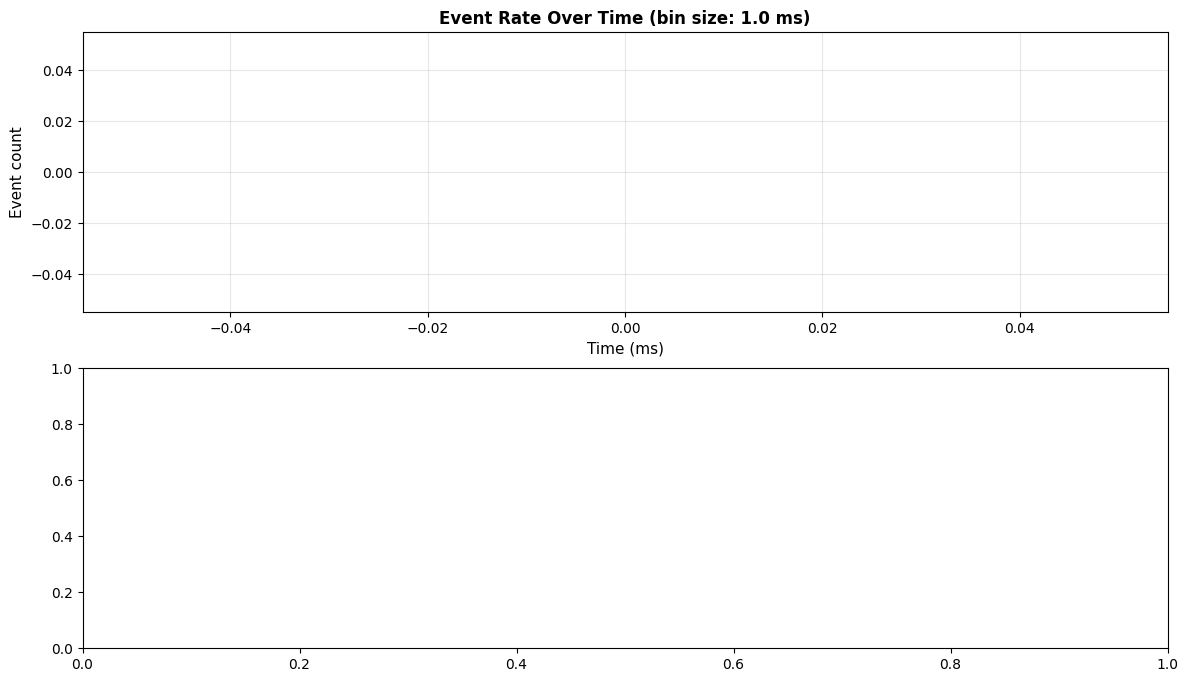

In [46]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Event rate over time
ax1 = axes[0]
bin_width_us = 1000  # 1ms bins
time_bins = np.arange(events['t'].min(), events['t'].max(), bin_width_us)
event_counts, _ = np.histogram(events['t'], bins=time_bins)
time_centers = time_bins[:-1] + bin_width_us / 2

ax1.plot(time_centers / 1000, event_counts, linewidth=1.5, color='blue')
ax1.fill_between(time_centers / 1000, event_counts, alpha=0.3, color='blue')
ax1.set_xlabel('Time (ms)', fontsize=11)
ax1.set_ylabel('Event count', fontsize=11)
ax1.set_title(f'Event Rate Over Time (bin size: {bin_width_us/1000:.1f} ms)', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)